# 32 — `lines`

`Map.lines` draws **line features** — roads, rivers, tracks, reach networks — and styles them from their own
attributes: a colour ramp over a value, a classification, a width, or a flat colour. It is the general-purpose
line renderer; `sankey` (next notebook) is the special case that sizes width by magnitude.

By the end you will be able to draw a line network, build a road hierarchy from per-class layers, ramp colour
over a numeric attribute, and classify a skewed one.

API: [`Map.lines`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832


## The data

2,320 road centrelines from **OpenStreetMap** over Heidelberg, each carrying its OSM tags: `klass` (the road
class), `lanes`, `maxspeed` in km/h, and a street `name`.

In [2]:
roads = FeatureCollection.read_file(str(DATA / "heidelberg_roads.geojson"))
print(f"{len(roads)} centrelines, EPSG:{roads.crs.to_epsg()}")
print("classes:", roads["klass"].value_counts().to_dict())
roads[["name", "klass", "lanes", "maxspeed"]].head()

2320 centrelines, EPSG:4326
classes: {'residential': 994, 'primary': 424, 'secondary': 377, 'tertiary': 270, 'living_street': 181, 'unclassified': 63, 'trunk': 11}


,name,klass,lanes,maxspeed
0,NaN,trunk,2.0,70.0
1,NaN,primary,2.0,50.0
2,Mönchhofstraße,tertiary,NaN,30.0
3,Im Neuenheimer Feld,residential,2.0,30.0
4,Czernyring,secondary,2.0,30.0


`maxspeed` is known for 1,950 of the 2,320 and `lanes` for 1,476 — partial attribute coverage is normal in OSM,
and it shapes what each figure below can honestly show.

## Quickstart — the network

With no styling, `lines` draws every feature in one colour. That is the map to look at first: the shape of the
network, before any value is layered on.

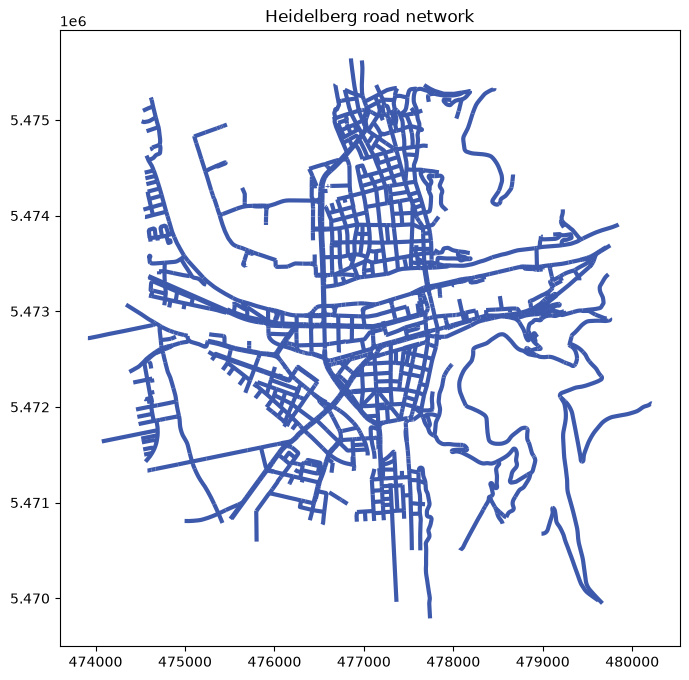

In [3]:
m = Map(crs=UTM32, figsize=(8, 8))
m.lines(roads)
m.set_title("Heidelberg road network")
m.fig;

The Neckar valley and the old town are visible purely from street density. But every road is equally weighted,
so a motorway looks like a cul-de-sac — which is what the hierarchy below fixes.

## A road hierarchy, as per-class layers

`column=` ramps colour over a **numeric** attribute; a road class is categorical, so the idiom is one `lines`
layer per class with its own `color` and `width`. That is also how cartographers actually draw roads: the
hierarchy is a styling decision, not a colour ramp.

In [4]:
HIERARCHY = {
    "trunk": ("#b2182b", 3.0), "primary": ("#ef8a62", 2.4),
    "secondary": ("#f4a582", 1.8), "tertiary": ("#92c5de", 1.3),
    "residential": ("#bbbbbb", 0.7), "living_street": ("#d4d4d4", 0.6),
    "unclassified": ("#dddddd", 0.6),
}

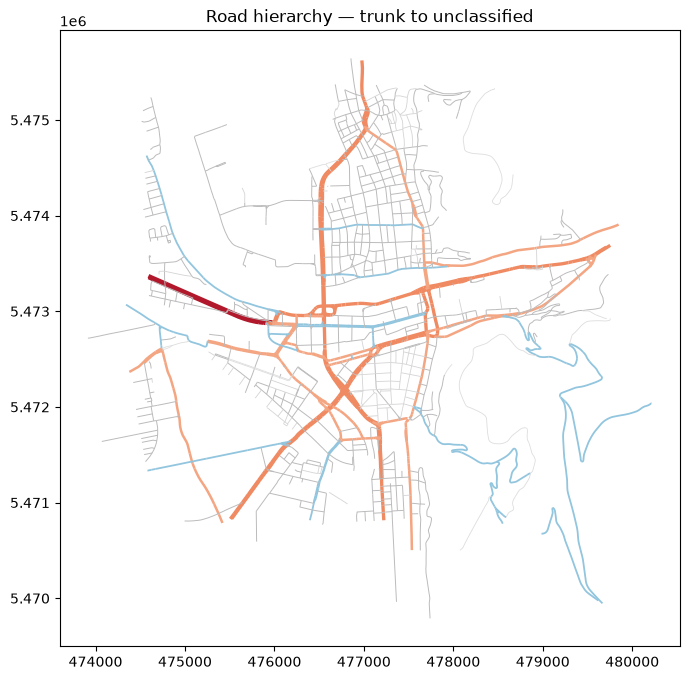

In [5]:
m = Map(crs=UTM32, figsize=(8, 8))
for klass, (color, width) in HIERARCHY.items():
    part = roads[roads["klass"] == klass]
    if len(part):
        m.lines(part, color=color, width=width, name=klass)
m.set_title("Road hierarchy — trunk to unclassified")
m.fig;

Now the network has structure: the trunk route and the primary radials carry the eye, and the residential mesh
recedes into texture. Each class is also a **named layer**, so it can be hidden or reordered afterwards — see
[`15_layer_management`](../15_layer_management.ipynb).

## Ramping colour over a value

For a genuinely numeric attribute, `column=` is the right tool. Speed limits are numeric and meaningful, so they
ramp well.

| argument | meaning | typical value |
|---|---|---|
| `column` | numeric attribute driving the colour | a numeric column |
| `scheme` | how values are binned | `"quantiles"`, `"equal_interval"`, `"natural_breaks"` |
| `k` | number of classes | `5` (default) |
| `width` | line width | a number |
| `color` | one flat colour for every line | a colour string |

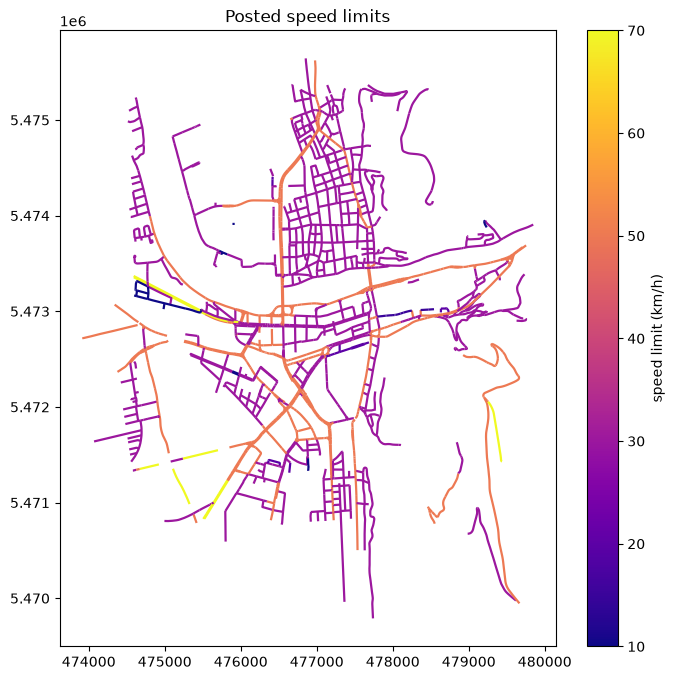

In [6]:
posted = FeatureCollection(roads.dropna(subset=["maxspeed"]))
m = Map(crs=UTM32, figsize=(8, 8))
m.lines(posted, column="maxspeed", cmap="plasma", width=1.6)
m.colorbar(label="speed limit (km/h)")
m.set_title("Posted speed limits")
m.fig;

The 30 km/h city core separates cleanly from the 50 km/h arterials and the faster edges. Note that this map
silently drops the 370 roads with no `maxspeed` tag — a continuous ramp cannot represent "unknown", so filtering
first and saying so is more honest than letting them fall to one end of the scale.

## Classifying a skewed attribute

`maxspeed` is dominated by two values (30 and 50), so a continuous ramp wastes most of its range. A
classification puts a comparable number of features in each class, so every colour is used.

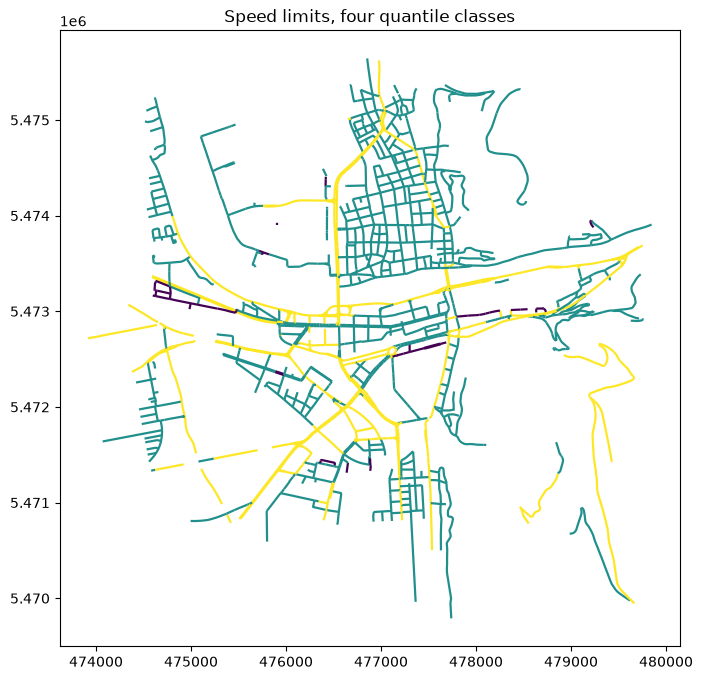

In [7]:
m = Map(crs=UTM32, figsize=(8, 8))
m.lines(posted, column="maxspeed", scheme="quantiles", k=4, cmap="viridis", width=1.6)
m.set_title("Speed limits, four quantile classes")
m.fig;

With four quantile classes the distinction between the 30 and 50 zones becomes the main division in the figure,
which is what the distribution actually supports.

## Takeaway

- `lines(features)` draws the network; a **categorical** hierarchy is one layer per class with its own
  `color`/`width`, not a `column=`.
- `column=` needs **numbers**; `scheme=` + `k=` classify a skewed numeric attribute.
- Filter out features missing the attribute, and say that you did — a ramp cannot show "unknown".
- For width that encodes magnitude, use [`33_sankey`](33_sankey.ipynb).

Next: [`33_sankey`](33_sankey.ipynb).